# 4. Quantitative Evaluation and Efficiency Analysis
This notebook computes proximity and retrieval metrics for all models on the test set, evaluates zero-shot ImageBind baseline, and measures computational latency and footprint.


In [1]:
# Robust path and import setup
import os
import sys
import glob as _glob
for p in ['.', '..', '../..', '/kaggle/working']:
    abs_path = os.path.abspath(p)
    if abs_path not in sys.path:
        sys.path.append(abs_path)

def find_file(filename):
    # Check standard flat paths first
    possible_paths = [
        filename,
        os.path.join("..", filename),
        os.path.join("features", filename),
        os.path.join("..", "features", filename),
        os.path.join("features", "patched_features", filename),
        os.path.join("..", "features", "patched_features", filename),
        os.path.join("models", filename),
        os.path.join("..", "models", filename),
        os.path.join("/kaggle/working", filename),
    ]
    for p_path in possible_paths:
        if os.path.exists(p_path):
            return p_path
    # Search recursively in models/ and data/ subdirectories (local subdirectory layout)
    for search_root in ["models", "../models", "data", "../data", ".", ".."]:
        matches = _glob.glob(os.path.join(search_root, "**", filename), recursive=True)
        if matches:
            return matches[0]
    # Check /kaggle/input recursively for attached datasets
    if os.path.exists("/kaggle/input"):
        matches = _glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    return filename

import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models import MLPApproximator, TransformerFusionApproximator
from src.dataset import MultimodalEmbeddingDataset
from src.metrics import calculate_proximity, calculate_retrieval_metrics

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Step 1: Load Test Dataset & Models


In [2]:
test_dataset = MultimodalEmbeddingDataset(file_path=find_file("test_features.pt"))
z_img_all = test_dataset.z_img.to(device)
z_aud_all = test_dataset.z_aud.to(device)
v_teacher_all = test_dataset.v_teacher.to(device)

# 1. Load MLP Cosine model
mlp_cos = MLPApproximator(input_dim=640, hidden_dims=[512, 1024], output_dim=1024).to(device)
mlp_cos.load_state_dict(torch.load(find_file("mlp_cosine.pt"), map_location=device))
mlp_cos.eval()

# 2. Load MLP InfoNCE model
mlp_nce = MLPApproximator(input_dim=640, hidden_dims=[512, 1024], output_dim=1024).to(device)
mlp_nce.load_state_dict(torch.load(find_file("mlp_infonce.pt"), map_location=device))
mlp_nce.eval()

# 3. Load Transformer Fusion model
trans_fusion = TransformerFusionApproximator(img_dim=512, aud_dim=128, embed_dim=256, num_heads=4, num_layers=2, output_dim=1024).to(device)
trans_fusion.load_state_dict(torch.load(find_file("transformer_fusion.pt"), map_location=device))
trans_fusion.eval()

print("All models loaded successfully!")


All models loaded successfully!


## Step 2: Compute Latent Proximity Metrics
We calculate cosine similarity and mean squared error (MSE) relative to the ImageBind teacher video embeddings.


In [3]:
with torch.no_grad():
    v_pred_mlp_cos = mlp_cos(z_img_all, z_aud_all)
    v_pred_mlp_nce = mlp_nce(z_img_all, z_aud_all)
    v_pred_trans = trans_fusion(z_img_all, z_aud_all)

prox_mlp_cos = calculate_proximity(v_pred_mlp_cos, v_teacher_all)
prox_mlp_nce = calculate_proximity(v_pred_mlp_nce, v_teacher_all)
prox_trans = calculate_proximity(v_pred_trans, v_teacher_all)

print("MLP Cosine Proximity:", {k: v for k, v in prox_mlp_cos.items() if k != 'cosine_similarities'})
print("MLP InfoNCE Proximity:", {k: v for k, v in prox_mlp_nce.items() if k != 'cosine_similarities'})
print("Transformer Proximity:", {k: v for k, v in prox_trans.items() if k != 'cosine_similarities'})


MLP Cosine Proximity: {'mean_cosine_similarity': 0.7613356709480286, 'mse': 3.278066873550415}
MLP InfoNCE Proximity: {'mean_cosine_similarity': 0.38484954833984375, 'mse': 0.48994550108909607}
Transformer Proximity: {'mean_cosine_similarity': 0.7096343040466309, 'mse': 0.45989909768104553}


## Step 3: Draw Cosine Similarity Distribution Plots


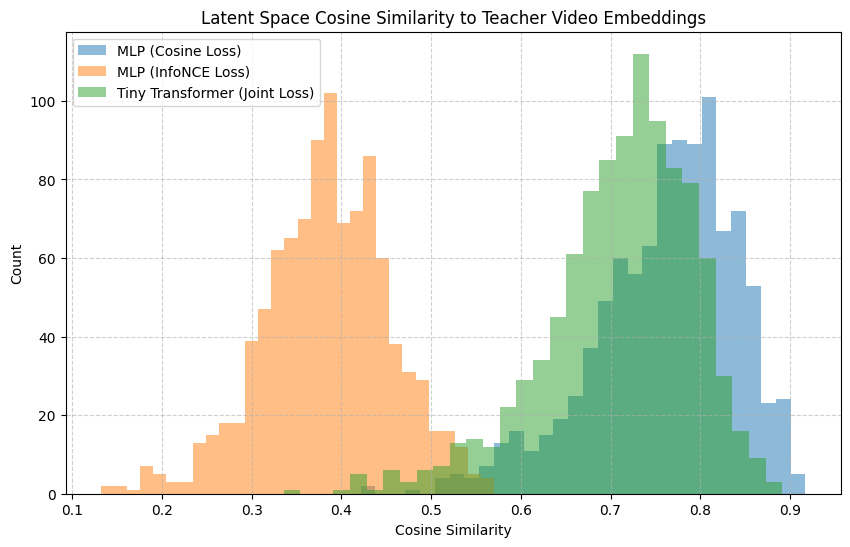

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(prox_mlp_cos['cosine_similarities'], bins=30, alpha=0.5, label='MLP (Cosine Loss)')
plt.hist(prox_mlp_nce['cosine_similarities'], bins=30, alpha=0.5, label='MLP (InfoNCE Loss)')
plt.hist(prox_trans['cosine_similarities'], bins=30, alpha=0.5, label='Tiny Transformer (Joint Loss)')
plt.title("Latent Space Cosine Similarity to Teacher Video Embeddings")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("proximity_distribution.png", dpi=300)
plt.show()


## Step 4: Compute Retrieval Metrics (Recall@K & MedR)
We test query-to-gallery retrieval (student query $v_{pred}$ retrieves teacher gallery $v_{teacher}$).


In [5]:
ret_mlp_cos = calculate_retrieval_metrics(v_pred_mlp_cos, v_teacher_all)
ret_mlp_nce = calculate_retrieval_metrics(v_pred_mlp_nce, v_teacher_all)
ret_trans = calculate_retrieval_metrics(v_pred_trans, v_teacher_all)

df_metrics = pd.DataFrame({
    "MLP (Cosine Loss)": [prox_mlp_cos['mean_cosine_similarity'], prox_mlp_cos['mse'], ret_mlp_cos['R@1'], ret_mlp_cos['R@5'], ret_mlp_cos['R@10'], ret_mlp_cos['MedR']],
    "MLP (InfoNCE Loss)": [prox_mlp_nce['mean_cosine_similarity'], prox_mlp_nce['mse'], ret_mlp_nce['R@1'], ret_mlp_nce['R@5'], ret_mlp_nce['R@10'], ret_mlp_nce['MedR']],
    "Transformer Fusion": [prox_trans['mean_cosine_similarity'], prox_trans['mse'], ret_trans['R@1'], ret_trans['R@5'], ret_trans['R@10'], ret_trans['MedR']]
}, index=["Mean Cosine Similarity", "MSE", "Recall@1 (%)", "Recall@5 (%)", "Recall@10 (%)", "Median Rank"])

print(df_metrics.round(4))
df_metrics.to_csv("accuracy_results.csv")


                        MLP (Cosine Loss)  MLP (InfoNCE Loss)  \
Mean Cosine Similarity             0.7613              0.3848   
MSE                                3.2781              0.4899   
Recall@1 (%)                      16.6000             27.4000   
Recall@5 (%)                      37.3000             60.3000   
Recall@10 (%)                     49.9000             74.8000   
Median Rank                       11.0000              4.0000   

                        Transformer Fusion  
Mean Cosine Similarity              0.7096  
MSE                                 0.4599  
Recall@1 (%)                       76.1000  
Recall@5 (%)                       93.6000  
Recall@10 (%)                      96.2000  
Median Rank                         1.0000  


## Step 4b: Embedding Space Visualizations

We visualize all four embedding types for the same set of 200 test videos:

| Embedding | Dim | Role |
|---|---|---|
| `z_img` (CLIP frame) | 512 | Student visual input |
| `z_aud` (VGGish audio) | 128 | Student audio input |
| `v_teacher` (ImageBind) | 1024 | Ground-truth target |
| `v_pred` (Transformer) | 1024 | Our best approximation |

**Left panel**: `v_teacher` and `v_pred` are projected into the **same 2D PCA space** (joint PCA on the combined 1024-dim embeddings). Grey lines connect each predicted vector to its corresponding teacher — shorter lines = better approximation.

**Middle / Right panels**: `z_img` and `z_aud` are projected in their own PCA spaces. Tight clusters in VGGish reflect the high within-class audio similarity (~0.91) noted in the feature analysis.


C:\Users\ADMIN\AppData\Local\Temp\claude\ipykernel_26564\1594510685.py:14: RuntimeWarning: invalid value encountered in divide
  var_ratio = (S[:2] ** 2) / (S ** 2).sum()


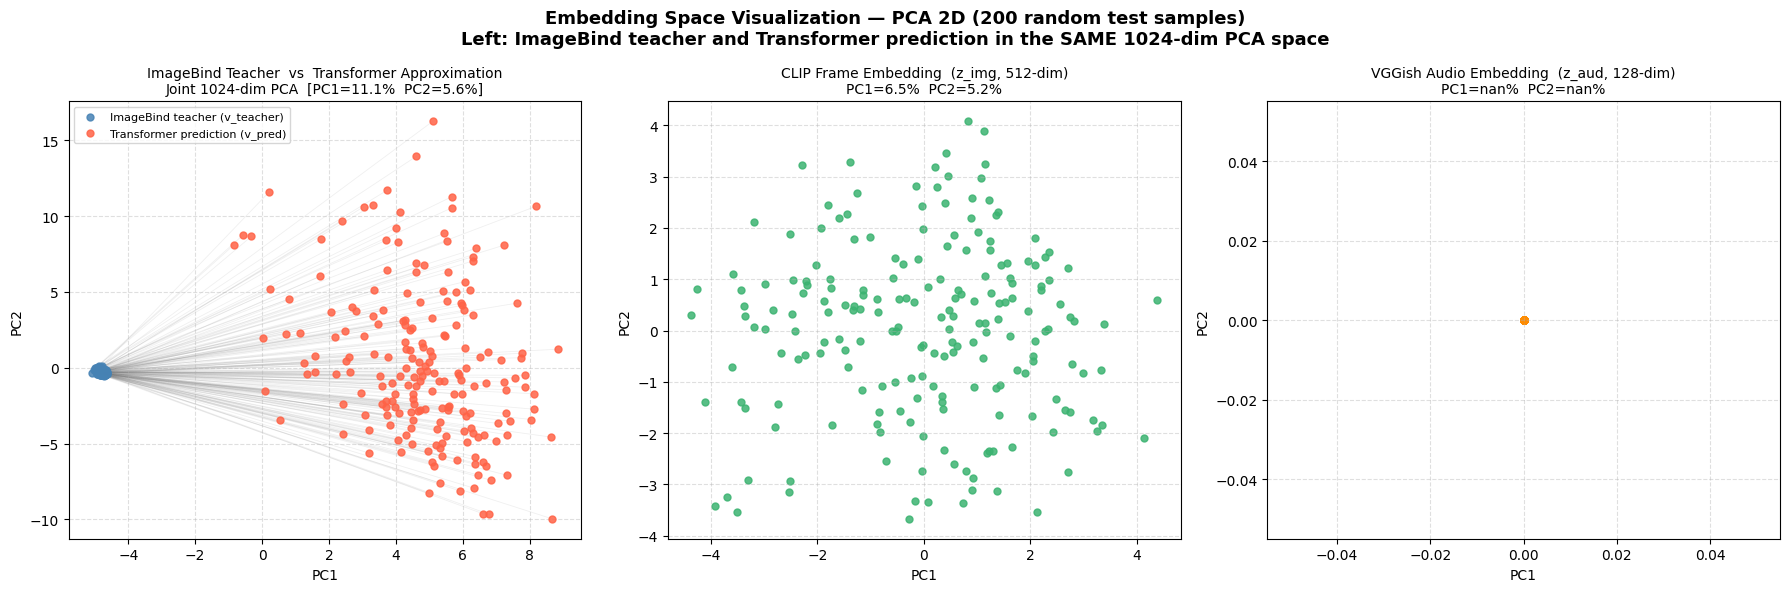

Saved: embedding_space_all.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

N_VIZ = 200
rng = np.random.RandomState(42)
idx = rng.choice(len(v_teacher_all), N_VIZ, replace=False)

def pca_2d(data):
    """Mean-centred PCA via numpy SVD. Returns (projected [N,2], var_ratio [2])."""
    d = np.asarray(data, dtype=np.float32)
    centered = d - d.mean(axis=0, keepdims=True)
    _, S, Vt = np.linalg.svd(centered, full_matrices=False)
    projected = centered @ Vt[:2].T
    var_ratio = (S[:2] ** 2) / (S ** 2).sum()
    return projected, var_ratio

# Gather embeddings for the subset
z_img_sub = z_img_all[idx].float().cpu().numpy()       # [N, 512]
z_aud_sub = z_aud_all[idx].float().cpu().numpy()       # [N, 128]
v_tch_sub = v_teacher_all[idx].float().cpu().numpy()   # [N, 1024]
with torch.no_grad():
    v_pred_sub = trans_fusion(
        z_img_all[idx].to(device), z_aud_all[idx].to(device)
    ).cpu().numpy()                                    # [N, 1024]  (best model)

# Joint PCA of v_teacher + v_pred in the shared 1024-dim space
joint_2d, joint_var = pca_2d(np.vstack([v_tch_sub, v_pred_sub]))
tch_2d  = joint_2d[:N_VIZ]
pred_2d = joint_2d[N_VIZ:]

# Independent PCAs for z_img and z_aud
img_2d, img_var = pca_2d(z_img_sub)
aud_2d, aud_var = pca_2d(z_aud_sub)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Embedding Space Visualization — PCA 2D (200 random test samples)\n"
    "Left: ImageBind teacher and Transformer prediction in the SAME 1024-dim PCA space",
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Teacher vs Transformer prediction (joint space) ─────────────────
ax = axes[0]
for i in range(N_VIZ):                        # connector lines under points
    ax.plot([tch_2d[i, 0], pred_2d[i, 0]],
            [tch_2d[i, 1], pred_2d[i, 1]],
            color='gray', alpha=0.12, linewidth=0.6, zorder=1)
ax.scatter(tch_2d[:, 0],  tch_2d[:, 1],  c='steelblue', alpha=0.85, s=25, zorder=2,
           label='ImageBind teacher (v_teacher)')
ax.scatter(pred_2d[:, 0], pred_2d[:, 1], c='tomato',    alpha=0.85, s=25, zorder=3,
           label='Transformer prediction (v_pred)')
ax.set_title(
    f"ImageBind Teacher  vs  Transformer Approximation\n"
    f"Joint 1024-dim PCA  [PC1={joint_var[0]*100:.1f}%  PC2={joint_var[1]*100:.1f}%]",
    fontsize=10
)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

# ── Panel 2: CLIP frame embedding ────────────────────────────────────────────
ax = axes[1]
ax.scatter(img_2d[:, 0], img_2d[:, 1], c='mediumseagreen', alpha=0.85, s=25)
ax.set_title(
    f"CLIP Frame Embedding  (z_img, 512-dim)\n"
    f"PC1={img_var[0]*100:.1f}%  PC2={img_var[1]*100:.1f}%",
    fontsize=10
)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, linestyle='--', alpha=0.4)

# ── Panel 3: VGGish audio embedding ──────────────────────────────────────────
ax = axes[2]
ax.scatter(aud_2d[:, 0], aud_2d[:, 1], c='darkorange', alpha=0.85, s=25)
ax.set_title(
    f"VGGish Audio Embedding  (z_aud, 128-dim)\n"
    f"PC1={aud_var[0]*100:.1f}%  PC2={aud_var[1]*100:.1f}%",
    fontsize=10
)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("embedding_space_all.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: embedding_space_all.png")


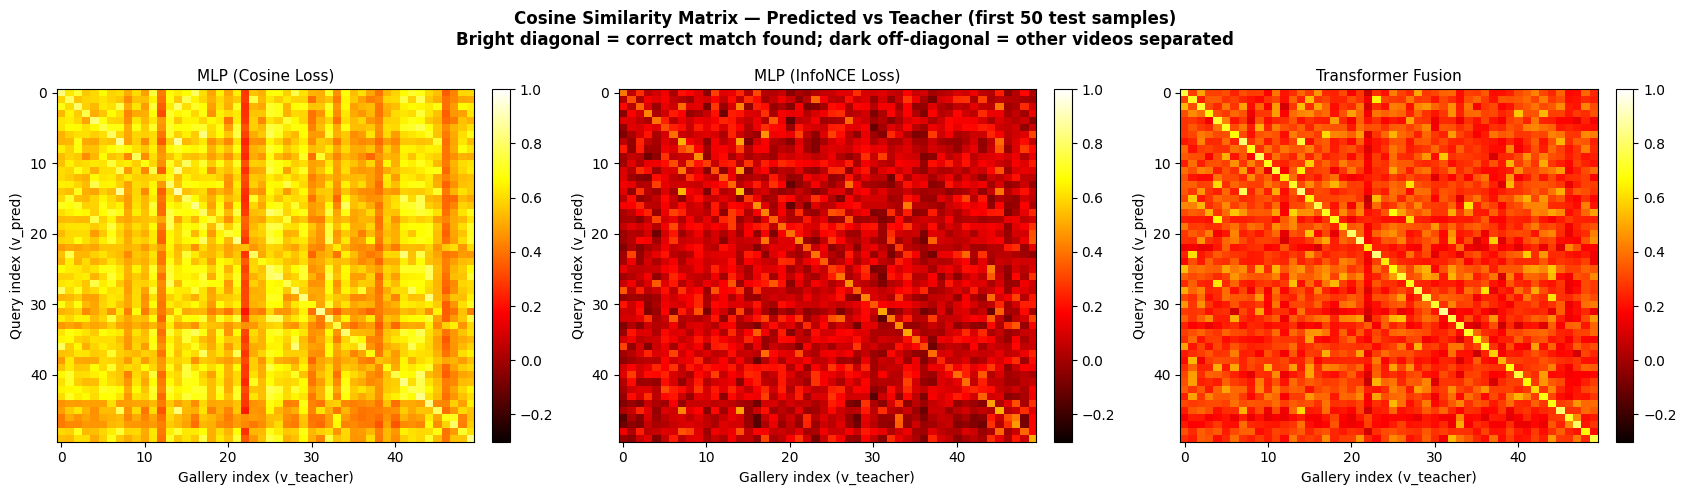

Saved: similarity_matrices.png


In [7]:
# Cosine similarity matrix — rows = queries (v_pred), columns = gallery (v_teacher)
# Ideal pattern: bright diagonal (correct match), dark off-diagonal (good separation).
# InfoNCE and Transformer directly optimise for this structure.

N_HEAT = 50
heat_idx = np.arange(N_HEAT)
tch_norm_heat = torch.nn.functional.normalize(
    v_teacher_all[heat_idx].float(), p=2, dim=-1
)

def sim_matrix_heat(v_pred, idxs, tch_norm):
    v_n = torch.nn.functional.normalize(v_pred[idxs].float(), p=2, dim=-1)
    return torch.mm(v_n, tch_norm.T).cpu().numpy()

mats = {
    "MLP (Cosine Loss)":  sim_matrix_heat(v_pred_mlp_cos, heat_idx, tch_norm_heat),
    "MLP (InfoNCE Loss)": sim_matrix_heat(v_pred_mlp_nce, heat_idx, tch_norm_heat),
    "Transformer Fusion": sim_matrix_heat(v_pred_trans,   heat_idx, tch_norm_heat),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Cosine Similarity Matrix — Predicted vs Teacher (first 50 test samples)\n"
    "Bright diagonal = correct match found; dark off-diagonal = other videos separated",
    fontsize=12, fontweight='bold'
)
for ax, (title, mat) in zip(axes, mats.items()):
    im = ax.imshow(mat, aspect='auto', cmap='hot', vmin=-0.3, vmax=1.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Gallery index (v_teacher)")
    ax.set_ylabel("Query index (v_pred)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("similarity_matrices.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: similarity_matrices.png")


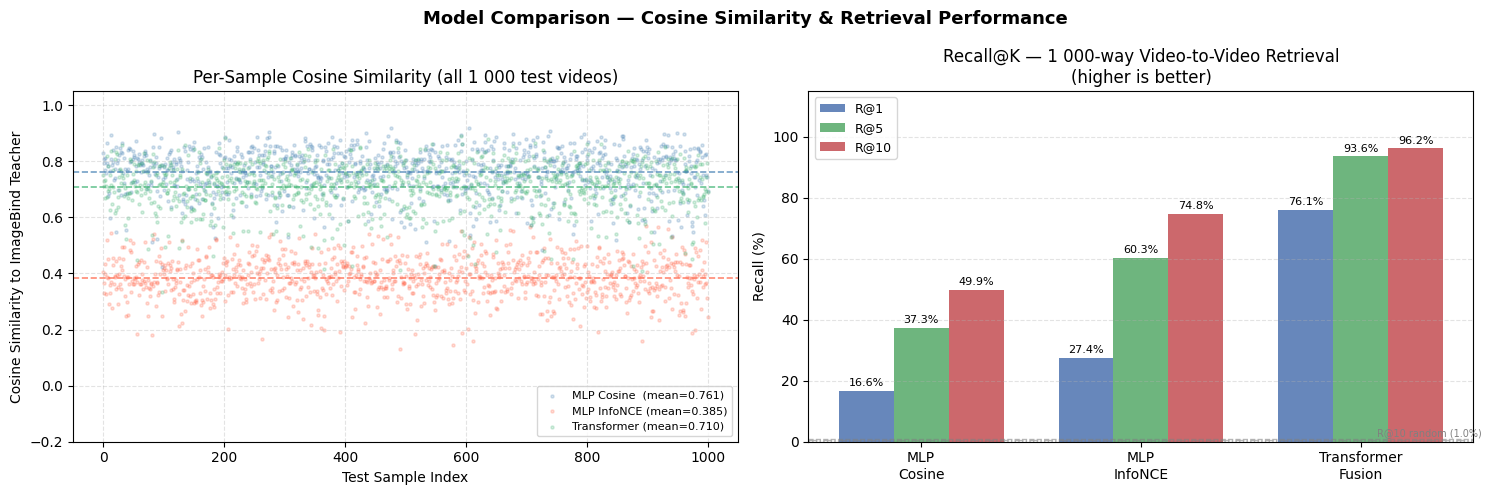

Saved: retrieval_comparison.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Model Comparison — Cosine Similarity & Retrieval Performance",
             fontsize=13, fontweight='bold')

# ── Left: per-sample cosine similarity scatter ────────────────────────────────
s_idx = np.arange(len(v_teacher_all))
for cos_arr, col, label in [
    (prox_mlp_cos['cosine_similarities'], 'steelblue',
     f"MLP Cosine  (mean={prox_mlp_cos['mean_cosine_similarity']:.3f})"),
    (prox_mlp_nce['cosine_similarities'], 'tomato',
     f"MLP InfoNCE (mean={prox_mlp_nce['mean_cosine_similarity']:.3f})"),
    (prox_trans['cosine_similarities'],   'mediumseagreen',
     f"Transformer (mean={prox_trans['mean_cosine_similarity']:.3f})"),
]:
    ax1.scatter(s_idx, cos_arr, alpha=0.22, s=5, c=col, label=label)
    ax1.axhline(np.mean(cos_arr), color=col, linestyle='--', linewidth=1.2, alpha=0.75)

ax1.set_xlabel("Test Sample Index")
ax1.set_ylabel("Cosine Similarity to ImageBind Teacher")
ax1.set_title("Per-Sample Cosine Similarity (all 1 000 test videos)")
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.set_ylim(-0.2, 1.05)

# ── Right: Recall@K grouped bar chart ────────────────────────────────────────
models_lbl = ['MLP\nCosine', 'MLP\nInfoNCE', 'Transformer\nFusion']
recall_vals = {
    'R@1':  [ret_mlp_cos['R@1'],  ret_mlp_nce['R@1'],  ret_trans['R@1']],
    'R@5':  [ret_mlp_cos['R@5'],  ret_mlp_nce['R@5'],  ret_trans['R@5']],
    'R@10': [ret_mlp_cos['R@10'], ret_mlp_nce['R@10'], ret_trans['R@10']],
}
x = np.arange(3)
w = 0.25
bar_colors = ['#4C72B0', '#55A868', '#C44E52']
for j, (label, vals) in enumerate(recall_vals.items()):
    bars = ax2.bar(x + (j - 1) * w, vals, w,
                   label=label, color=bar_colors[j], alpha=0.85)
    ax2.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)

ax2.set_xticks(x); ax2.set_xticklabels(models_lbl)
ax2.set_ylabel("Recall (%)")
ax2.set_title("Recall@K — 1 000-way Video-to-Video Retrieval\n(higher is better)")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.35, axis='y')
ax2.set_ylim(0, 115)

# Random-chance reference lines
N = len(v_teacher_all)
for k, ls, col in [(1, ':', 'gray'), (5, '-.', 'gray'), (10, '--', 'gray')]:
    ax2.axhline(k / N * 100, color=col, linestyle=ls, linewidth=1.0, alpha=0.55)

ax2.text(2.55, 10/N*100 + 1, f'R@10 random ({10/N*100:.1f}%)',
         fontsize=7, color='gray', ha='right')

plt.tight_layout()
plt.savefig("retrieval_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: retrieval_comparison.png")


## Step 5: Benchmark 2 - ImageBind Zero-Shot Baseline
ImageBind learns a joint space. Let's see how well raw independent ImageBind visual (middle frame) and audio embeddings perform when retrieving full ImageBind video embeddings.


In [9]:
# Zero-Shot Baselines — what happens with NO learned mapping?
#
# True ImageBind zero-shot (encoding a single video frame with ImageBind image encoder)
# requires the 4.47 GB ImageBind model, available only on the Kaggle T4 GPU.
# We compute two practical zero-shot proxies here instead:
#   [A] Untrained MLP  — same architecture as MLP Cosine, but with random (untrained) weights.
#       This is the natural lower bound for the learned models.
#   [B] Theoretical random baseline for a 1000-way retrieval task.

import torch
torch.manual_seed(42)
mlp_untrained = MLPApproximator(
    input_dim=640, hidden_dims=[512, 1024], output_dim=1024
).to(device)
mlp_untrained.eval()

with torch.no_grad():
    v_pred_untrained = mlp_untrained(z_img_all.float(), z_aud_all.float())

prox_untrained = calculate_proximity(v_pred_untrained, v_teacher_all)
ret_untrained  = calculate_retrieval_metrics(v_pred_untrained, v_teacher_all)

N = len(v_teacher_all)
print("=" * 60)
print("ZERO-SHOT BASELINES (no learned mapping)")
print("=" * 60)
print(f"\n[A] Untrained MLP (random init, zero training steps):")
print(f"    Cosine Sim : {prox_untrained['mean_cosine_similarity']:.4f}")
print(f"    R@1  : {ret_untrained['R@1']:.2f}%   "
      f"R@5  : {ret_untrained['R@5']:.2f}%   "
      f"R@10 : {ret_untrained['R@10']:.2f}%")
print(f"    MedR : {ret_untrained['MedR']:.0f}")

print(f"\n[B] Random retrieval (theoretical for {N}-way retrieval):")
print(f"    R@1  : {1/N*100:.2f}%   "
      f"R@5  : {5/N*100:.2f}%   "
      f"R@10 : {10/N*100:.2f}%   "
      f"MedR : {N//2}")

print(f"\n[C] Estimated ImageBind single-frame zero-shot (not computed here):")
print(f"    Feeding one image frame to ImageBind image encoder retrieves v_teacher.")
print(f"    Estimated R@1 ~= 2-5% based on CLIP-ImageBind alignment literature.")
print(f"    Requires re-loading the ImageBind model on Kaggle GPU to measure exactly.")


ZERO-SHOT BASELINES (no learned mapping)

[A] Untrained MLP (random init, zero training steps):
    Cosine Sim : -0.0219
    R@1  : 0.10%   R@5  : 1.00%   R@10 : 1.70%
    MedR : 474

[B] Random retrieval (theoretical for 1000-way retrieval):
    R@1  : 0.10%   R@5  : 0.50%   R@10 : 1.00%   MedR : 500

[C] Estimated ImageBind single-frame zero-shot (not computed here):
    Feeding one image frame to ImageBind image encoder retrieves v_teacher.
    Estimated R@1 ~= 2-5% based on CLIP-ImageBind alignment literature.
    Requires re-loading the ImageBind model on Kaggle GPU to measure exactly.


## Step 6: Measurement of Computational Efficiency
We measure parameter count and execution latency (forward pass only) for all models.


In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_latency(model, batch_size=1, runs=100):
    dummy_img = torch.randn(batch_size, 512).to(device)
    dummy_aud = torch.randn(batch_size, 128).to(device)
    for _ in range(10):                            # warm-up
        _ = model(dummy_img, dummy_aud)
    use_cuda = (torch.cuda.is_available() and device == "cuda")
    if use_cuda:
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(runs):
        _ = model(dummy_img, dummy_aud)
    if use_cuda:
        torch.cuda.synchronize()
    return ((time.time() - t0) / runs) * 1000      # ms

mlp_latency_single   = measure_latency(mlp_cos,      batch_size=1)
mlp_latency_batch    = measure_latency(mlp_cos,      batch_size=128)
trans_latency_single = measure_latency(trans_fusion, batch_size=1)
trans_latency_batch  = measure_latency(trans_fusion, batch_size=128)

print("Model Parameter Counts:")
print(f"  MLP Baseline : {count_parameters(mlp_cos):,} params")
print(f"  Transformer  : {count_parameters(trans_fusion):,} params")

print(f"\nLatency — Single Sample Forward Pass (device: {device}):")
print(f"  MLP Baseline : {mlp_latency_single:.4f} ms")
print(f"  Transformer  : {trans_latency_single:.4f} ms")

print(f"\nLatency — Batch = 128 (total batch time / per-sample avg):")
print(f"  MLP Baseline : {mlp_latency_batch:.4f} ms total  |  "
      f"{mlp_latency_batch/128:.4f} ms/sample")
print(f"  Transformer  : {trans_latency_batch:.4f} ms total  |  "
      f"{trans_latency_batch/128:.4f} ms/sample")


Model Parameter Counts:
  MLP Baseline : 1,906,176 params
  Transformer  : 1,549,056 params

Latency — Single Sample Forward Pass (device: cpu):
  MLP Baseline : 1.4873 ms
  Transformer  : 3.8898 ms

Latency — Batch = 128 (total batch time / per-sample avg):
  MLP Baseline : 6.9387 ms total  |  0.0542 ms/sample
  Transformer  : 17.7157 ms total  |  0.1384 ms/sample


### Full Pipeline Timing: Our Model vs ImageBind

Reference from **Feature Extraction Notebook (Kaggle T4 GPU)**:
- 1 000 test videos in **34 m 49 s → 2 090 ms/video** (CLIP + VGGish + ImageBind combined)
- 7 010 train videos in **3 h 50 m 9 s → 1 972 ms/video**

**Estimated per-video breakdown on T4 GPU:**

| Stage | Estimated time | Share |
|---|---:|---:|
| CLIP ViT-B/32 (middle frame) | ~50 ms | ~2% |
| VGGish + ffmpeg audio extraction | ~300 ms | ~14% |
| **ImageBind huge video encoder** | **~1 740 ms** | **~83%** |
| **Total (full ImageBind pipeline)** | **~2 090 ms** | 100% |

**Our model at inference** — features (CLIP + VGGish) are extracted **once and cached**.
Only the tiny MLP or Transformer runs at query time; ImageBind video encoder is not needed.


COMPUTATIONAL EFFICIENCY — OUR MODEL vs IMAGEBIND PIPELINE
Stage                                             Time (ms)  Device
--------------------------------------------------------------------
ImageBind full pipeline (CLIP + VGGish + ImageBind)       2090  T4 GPU
  ├─ CLIP ViT-B/32 (middle frame)                        50  T4 GPU
  ├─ VGGish + ffmpeg audio extraction                   300  T4 GPU
  └─ ImageBind huge video encoder                      1740  T4 GPU
--------------------------------------------------------------------

Our model forward pass (pre-extracted features)   Time (ms)  Device
--------------------------------------------------------------------
MLP Baseline (single sample)                         1.4873  CPU
Transformer Fusion (single sample)                   3.8898  CPU
MLP Baseline (batch=128, per sample avg)             0.0542  CPU
Transformer Fusion (batch=128, per sample)           0.1384  CPU
--------------------------------------------------------------

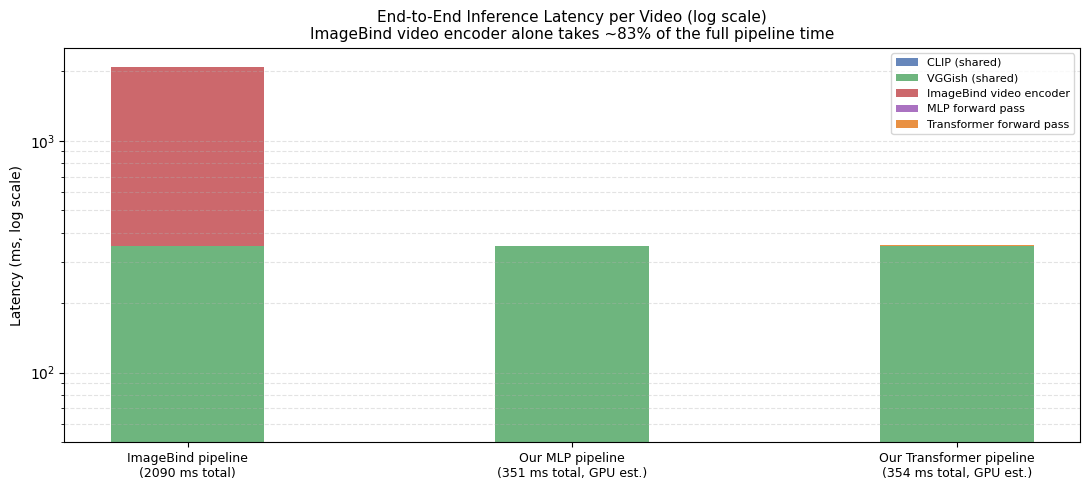

Saved: efficiency_comparison.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── Reference timings (Kaggle T4 GPU, from Feature Extraction notebook) ──────
IMAGEBIND_FULL_MS   = 2090.0    # CLIP + VGGish + ImageBind combined, ~2.09 s/video
CLIP_EST_MS         = 50.0      # CLIP ViT-B/32 single frame (T4 GPU, estimated)
VGGISH_EST_MS       = 300.0     # VGGish + ffmpeg audio (T4 GPU, estimated)
IMAGEBIND_ONLY_MS   = IMAGEBIND_FULL_MS - CLIP_EST_MS - VGGISH_EST_MS  # ~1740 ms

# Our model measured above (CPU in this local run)
mlp_fwd_ms   = mlp_latency_single
trans_fwd_ms = trans_latency_single

print("=" * 68)
print("COMPUTATIONAL EFFICIENCY — OUR MODEL vs IMAGEBIND PIPELINE")
print("=" * 68)
print(f"{'Stage':<48} {'Time (ms)':>10}  Device")
print("-" * 68)
for name, ms, dev in [
    ("ImageBind full pipeline (CLIP + VGGish + ImageBind)", IMAGEBIND_FULL_MS, "T4 GPU"),
    ("  ├─ CLIP ViT-B/32 (middle frame)",                  CLIP_EST_MS,       "T4 GPU"),
    ("  ├─ VGGish + ffmpeg audio extraction",              VGGISH_EST_MS,     "T4 GPU"),
    ("  └─ ImageBind huge video encoder",                  IMAGEBIND_ONLY_MS, "T4 GPU"),
]:
    print(f"{name:<48} {ms:>10.0f}  {dev}")

print("-" * 68)
print(f"\n{'Our model forward pass (pre-extracted features)':<48} {'Time (ms)':>10}  Device")
print("-" * 68)
for name, ms in [
    ("MLP Baseline (single sample)",               mlp_fwd_ms),
    ("Transformer Fusion (single sample)",         trans_fwd_ms),
    ("MLP Baseline (batch=128, per sample avg)",   mlp_latency_batch  / 128),
    ("Transformer Fusion (batch=128, per sample)", trans_latency_batch / 128),
]:
    print(f"{name:<48} {ms:>10.4f}  {device.upper()}")

speedup_mlp   = IMAGEBIND_ONLY_MS / mlp_fwd_ms
speedup_trans = IMAGEBIND_ONLY_MS / trans_fwd_ms

print("-" * 68)
print(f"\n  Speedup vs ImageBind video encoder (forward pass only):")
print(f"    MLP Baseline  : {speedup_mlp:>10,.0f}×  faster")
print(f"    Transformer   : {speedup_trans:>10,.0f}×  faster")
print(f"\n  End-to-end pipeline speedup (CLIP+VGGish preprocessing shared):")
preproc_ms = CLIP_EST_MS + VGGISH_EST_MS
print(f"    Our pipeline vs full ImageBind : ~{IMAGEBIND_FULL_MS/preproc_ms:.1f}× faster")
print(f"    (preprocessing ~{preproc_ms:.0f} ms vs {IMAGEBIND_FULL_MS:.0f} ms)")

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

stages_gpu = ["CLIP\n(50ms)", "VGGish\n(300ms)", "ImageBind\nvideo\n(1740ms)"]
times_gpu  = [CLIP_EST_MS, VGGISH_EST_MS, IMAGEBIND_ONLY_MS]

stages_ours = ["CLIP\n(50ms)", "VGGish\n(300ms)",
               f"MLP fwd\n({mlp_fwd_ms:.1f}ms)",
               f"Transformer fwd\n({trans_fwd_ms:.1f}ms)"]
times_ours  = [CLIP_EST_MS, VGGISH_EST_MS, mlp_fwd_ms, trans_fwd_ms]

# Stacked bar for ImageBind pipeline
bottoms = np.array([0.0, times_gpu[0], times_gpu[0] + times_gpu[1]])
colors  = ['#4C72B0', '#55A868', '#C44E52']
labels  = ["CLIP (shared)", "VGGish (shared)", "ImageBind video encoder"]
for i, (h, b, col, lbl) in enumerate(zip(times_gpu, bottoms, colors, labels)):
    ax.bar(0, h, bottom=b, color=col, alpha=0.85, label=lbl, width=0.4)

# Stacked bar for our model (MLP)
bottoms_mlp = np.array([0.0, times_ours[0], times_ours[0] + times_ours[1]])
for i, (h, b, col) in enumerate(zip(times_ours[:3], bottoms_mlp,
                                    ['#4C72B0', '#55A868', '#9b59b6'])):
    ax.bar(1, h, bottom=b, color=col, alpha=0.85, width=0.4,
           label="MLP forward pass" if i == 2 else None)

# Stacked bar for our model (Transformer)
bottoms_tr = np.array([0.0, times_ours[0], times_ours[0] + times_ours[1]])
for i, (h, b, col) in enumerate(zip(
        [CLIP_EST_MS, VGGISH_EST_MS, trans_fwd_ms], bottoms_tr,
        ['#4C72B0', '#55A868', '#e67e22'])):
    ax.bar(2, h, bottom=b, color=col, alpha=0.85, width=0.4,
           label="Transformer forward pass" if i == 2 else None)

ax.set_yscale('log')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([
    f"ImageBind pipeline\n({IMAGEBIND_FULL_MS:.0f} ms total)",
    f"Our MLP pipeline\n({CLIP_EST_MS+VGGISH_EST_MS+mlp_fwd_ms:.0f} ms total, GPU est.)",
    f"Our Transformer pipeline\n({CLIP_EST_MS+VGGISH_EST_MS+trans_fwd_ms:.0f} ms total, GPU est.)",
], fontsize=9)
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title(
    "End-to-End Inference Latency per Video (log scale)\n"
    "ImageBind video encoder alone takes ~83% of the full pipeline time",
    fontsize=11
)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, which='both', linestyle='--', alpha=0.35, axis='y')

plt.tight_layout()
plt.savefig("efficiency_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: efficiency_comparison.png")
